# Dataset Quality Check

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent.resolve()

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError(
        f"Could not find src directory at: {PROJECT_ROOT / 'src'}"
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("src directory:", PROJECT_ROOT / "src")

Project root: D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction
src directory: D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\src


In [2]:
from src.data.pairing import build_recording_pairs
from src.preprocessing.pipeline import process_sleep_edf_subject

pairings = build_recording_pairs(
    PROJECT_ROOT / "data" / "raw"
)

print("Number of recording pairs:", len(pairings))

Number of recording pairs: 197


In [3]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent.resolve()

FEATURES_PATH = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "sleep_edf_features_before_quality_filter.csv"
)

df = pd.read_csv(FEATURES_PATH)

print("Dataset path:")
print(FEATURES_PATH)

print("\nShape:")
print(df.shape)

print("\nNumber of subjects:")
print(df["subject_id"].nunique())

print("\nFirst 5 rows:")
display(df.head())

Dataset path:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\data\features\sleep_edf_features_before_quality_filter.csv

Shape:
(456640, 16)

Number of subjects:
197

First 5 rows:


,subject_id,epoch_index,start_time,end_time,raw_stage,target_stage,delta_absolute,theta_absolute,alpha_absolute,beta_absolute,delta_relative,theta_relative,alpha_relative,beta_relative,spectral_entropy,dominant_frequency
0,SC4001,0,0.0,30.0,Sleep stage W,W,4.440571e-10,9.889418e-11,8.991909e-12,1.013694e-11,0.790025,0.175943,0.015998,0.018035,0.667405,0.585938
1,SC4001,1,30.0,60.0,Sleep stage W,W,2.597151e-10,4.180098e-11,1.341957e-11,2.940132e-11,0.754247,0.121396,0.038972,0.085385,0.755591,1.074219
2,SC4001,2,60.0,90.0,Sleep stage W,W,3.779352e-10,2.401454e-11,1.257038e-11,1.754188e-11,0.874724,0.055581,0.029094,0.040600,0.604871,1.171875
3,SC4001,3,90.0,120.0,Sleep stage W,W,2.028651e-10,1.827274e-11,1.337502e-11,7.659840e-12,0.837688,0.075453,0.055229,0.031630,0.656860,1.660156
4,SC4001,4,120.0,150.0,Sleep stage W,W,1.260171e-10,4.473053e-11,9.939413e-12,6.435664e-12,0.673446,0.239044,0.053117,0.034393,0.715088,2.050781


In [4]:
print("Columns:")
for column in df.columns:
    print(f"  - {column}")

Columns:
  - subject_id
  - epoch_index
  - start_time
  - end_time
  - raw_stage
  - target_stage
  - delta_absolute
  - theta_absolute
  - alpha_absolute
  - beta_absolute
  - delta_relative
  - theta_relative
  - alpha_relative
  - beta_relative
  - spectral_entropy
  - dominant_frequency


In [5]:
print("Epochs per subject:")
print(
    df.groupby("subject_id")
      .size()
      .describe()
)

print("\nSubjects by dataset:")
print(
    df["subject_id"]
      .str[:2]
      .value_counts()
)

Epochs per subject:
count     197.000000
mean     2317.969543
std       745.104984
min       671.000000
25%      2342.000000
50%      2710.000000
75%      2780.000000
max      2880.000000
dtype: float64

Subjects by dataset:
subject_id
SC    414659
ST     41981
Name: count, dtype: int64


**Missing and infinite values**

In [6]:
feature_columns = [
    "delta_absolute",
    "theta_absolute",
    "alpha_absolute",
    "beta_absolute",
    "delta_relative",
    "theta_relative",
    "alpha_relative",
    "beta_relative",
    "spectral_entropy",
    "dominant_frequency",
]

print("NaN values:")
print(
    df[feature_columns]
    .isna()
    .sum()
)

print("\nTotal NaN values:")
print(
    df[feature_columns]
    .isna()
    .sum()
    .sum()
)

print("\nInfinite values:")
print(
    df[feature_columns]
    .isin(
        [float("inf"), float("-inf")]
    )
    .sum()
    .sum()
)

NaN values:
delta_absolute        0
theta_absolute        0
alpha_absolute        0
beta_absolute         0
delta_relative        0
theta_relative        0
alpha_relative        0
beta_relative         0
spectral_entropy      0
dominant_frequency    0
dtype: int64

Total NaN values:
0

Infinite values:
0


**Check target labels**

In [7]:
print("Unique target stages:")
print(
    sorted(
        df["target_stage"]
        .unique()
    )
)

print("\nTarget-stage distribution:")
print(
    df["target_stage"]
    .value_counts()
)

print("\nTarget-stage percentages:")
print(
    (
        df["target_stage"]
        .value_counts(
            normalize=True
        )
        * 100
    ).round(2)
)

Unique target stages:
['N1', 'N2', 'N3', 'REM', 'W']

Target-stage distribution:
target_stage
W      289410
N2      88637
REM     34073
N1      25091
N3      19429
Name: count, dtype: int64

Target-stage percentages:
target_stage
W      63.38
N2     19.41
REM     7.46
N1      5.49
N3      4.25
Name: proportion, dtype: float64


**Check duplicate epochs**

In [8]:
duplicate_mask = df.duplicated(
    subset=[
        "subject_id",
        "epoch_index",
    ],
    keep=False,
)

print(
    "Duplicate subject/epoch pairs:"
)

print(
    duplicate_mask.sum()
)

if duplicate_mask.sum() > 0:
    print("\nExamples:")
    display(
        df.loc[
            duplicate_mask
        ].sort_values(
            [
                "subject_id",
                "epoch_index",
            ]
        ).head(20)
    )

Duplicate subject/epoch pairs:
0


**Check epoch continuity**

In [9]:
def find_epoch_gaps(group):
    indices = (
        group["epoch_index"]
        .sort_values()
        .to_numpy()
    )

    if len(indices) == 0:
        return []

    expected = range(
        indices[0],
        indices[-1] + 1,
    )

    actual = set(indices)

    return [
        index
        for index in expected
        if index not in actual
    ]


gaps = {}

for subject_id, group in df.groupby(
    "subject_id"
):
    missing = find_epoch_gaps(group)

    if missing:
        gaps[subject_id] = missing


print(
    "Subjects with epoch-index gaps:"
)

print(
    len(gaps)
)

if gaps:
    for subject_id, missing in list(
        gaps.items()
    )[:10]:
        print(
            subject_id,
            "->",
            missing[:20],
        )

Subjects with epoch-index gaps:
61
SC4002 -> [936]
SC4022 -> [1255]
SC4041 -> [1366]
SC4042 -> [1299, 1374, 1484, 1511]
SC4052 -> [1187, 1373]
SC4091 -> [969, 1116, 1117, 1132, 1169, 1262, 1273, 1361, 1388, 1570, 1746]
SC4092 -> [1039, 1058, 1154, 1332, 1502, 1599, 1619, 1682, 1715, 1731, 1790, 1893]
SC4101 -> [1599]
SC4102 -> [1320]
SC4111 -> [1174]


**Check temporal ordering**

In [10]:
ordering_problems = []

for subject_id, group in df.groupby(
    "subject_id"
):
    sorted_group = group.sort_values(
        "epoch_index"
    )

    if not sorted_group[
        "start_time"
    ].is_monotonic_increasing:
        ordering_problems.append(
            subject_id
        )


print(
    "Subjects with incorrect temporal ordering:"
)

print(
    len(ordering_problems)
)

if ordering_problems:
    print(
        ordering_problems
    )

Subjects with incorrect temporal ordering:
0


**Verify the 30-second epochs**

In [11]:
epoch_durations = (
    df["end_time"]
    - df["start_time"]
)

print(
    "Unique epoch durations:"
)

print(
    epoch_durations
    .value_counts()
    .sort_index()
)

print(
    "\nAll epochs exactly 30 seconds:"
)

print(
    (epoch_durations == 30.0).all()
)

Unique epoch durations:
30.0    456640
Name: count, dtype: int64

All epochs exactly 30 seconds:
True


**Build a subject-level summary**

In [12]:
stage_order = [
    "W",
    "N1",
    "N2",
    "N3",
    "REM",
]

subject_stage_counts = (
    df.groupby(
        ["subject_id", "target_stage"]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reindex(
        columns=stage_order,
        fill_value=0,
    )
)

subject_stage_percentages = (
    subject_stage_counts.div(
        subject_stage_counts.sum(axis=1),
        axis=0,
    )
    * 100
)

print("Subject-level epoch counts:")
display(
    subject_stage_counts.head(10)
)

print("\nSubject-level stage percentages:")
display(
    subject_stage_percentages.head(10)
)

Subject-level epoch counts:


target_stage,W,N1,N2,N3,REM
subject_id,,,,,
SC4001,1997,58,250,220,125
SC4002,1884,59,373,297,215
SC4011,1856,109,562,105,170
SC4012,1824,92,660,96,176
SC4021,1907,94,545,95,163
SC4022,1870,184,402,119,179
SC4031,2008,61,485,57,209
SC4032,1957,45,400,131,199
SC4041,1533,166,620,53,196



Subject-level stage percentages:


target_stage,W,N1,N2,N3,REM
subject_id,,,,,
SC4001,75.358491,2.188679,9.433962,8.301887,4.716981
SC4002,66.619519,2.086280,13.189533,10.502122,7.602546
SC4011,66.238401,3.890079,20.057102,3.747323,6.067095
SC4012,64.044944,3.230337,23.174157,3.370787,6.179775
SC4021,68.009986,3.352354,19.436519,3.388017,5.813124
SC4022,67.901235,6.681191,14.596950,4.320988,6.499637
SC4031,71.205674,2.163121,17.198582,2.021277,7.411348
SC4032,71.632504,1.647145,14.641288,4.795022,7.284041
SC4041,59.696262,6.464174,24.143302,2.063863,7.632399


**Inspect the minimum class counts per subject**

In [13]:
print("Minimum number of epochs for each stage across subjects:")
print(
    subject_stage_counts[
        stage_order
    ].min()
)

print("\nNumber of subjects containing at least one epoch of each stage:")

for stage in stage_order:
    count = (
        subject_stage_counts[stage] > 0
    ).sum()

    print(
        f"{stage:>3}: {count} subjects"
    )

Minimum number of epochs for each stage across subjects:
target_stage
W       14
N1      13
N2     170
N3       0
REM     24
dtype: int64

Number of subjects containing at least one epoch of each stage:
  W: 197 subjects
 N1: 197 subjects
 N2: 197 subjects
 N3: 178 subjects
REM: 197 subjects


**Identify subjects with very little N1 or N3**

In [14]:
print("Subjects with fewer than 10 N1 epochs:")

display(
    subject_stage_counts[
        subject_stage_counts["N1"] < 10
    ][
        ["W", "N1", "N2", "N3", "REM"]
    ]
)

print("\nSubjects with fewer than 10 N3 epochs:")

display(
    subject_stage_counts[
        subject_stage_counts["N3"] < 10
    ][
        ["W", "N1", "N2", "N3", "REM"]
    ]
)

Subjects with fewer than 10 N1 epochs:


target_stage,W,N1,N2,N3,REM
subject_id,,,,,



Subjects with fewer than 10 N3 epochs:


target_stage,W,N1,N2,N3,REM
subject_id,,,,,
SC4101,1769,65,671,6,207
SC4201,2043,39,539,4,177
SC4202,1864,120,479,0,207
SC4232,1817,382,213,1,217
SC4242,1879,94,556,5,176
SC4321,1774,204,424,0,286
SC4322,1755,144,475,1,241
SC4331,1975,212,453,0,168
SC4332,1879,91,648,0,138


**Create subject-level stratification data**

In [15]:
subject_counts = (
    df.groupby(
        ["subject_id", "target_stage"]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reindex(
        columns=[
            "W",
            "N1",
            "N2",
            "N3",
            "REM",
        ],
        fill_value=0,
    )
)

print("Subject-level matrix shape:")
print(subject_counts.shape)

print("\nFirst 10 subjects:")
display(subject_counts.head(10))

Subject-level matrix shape:
(197, 5)

First 10 subjects:


target_stage,W,N1,N2,N3,REM
subject_id,,,,,
SC4001,1997,58,250,220,125
SC4002,1884,59,373,297,215
SC4011,1856,109,562,105,170
SC4012,1824,92,660,96,176
SC4021,1907,94,545,95,163
SC4022,1870,184,402,119,179
SC4031,2008,61,485,57,209
SC4032,1957,45,400,131,199
SC4041,1533,166,620,53,196


**Create a stratification score**

In [16]:
global_class_counts = (
    df["target_stage"]
    .value_counts()
    .reindex(
        ["W", "N1", "N2", "N3", "REM"]
    )
)

global_class_proportions = (
    global_class_counts
    / global_class_counts.sum()
)

print("Global class proportions:")
print(
    global_class_proportions
)

Global class proportions:
target_stage
W      0.633782
N1     0.054947
N2     0.194107
N3     0.042548
REM    0.074617
Name: count, dtype: float64


**Generate a reproducible subject-wise split**

In [17]:
import numpy as np

RANDOM_SEED = 42

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

assert abs(
    TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0
) < 1e-9

subjects = subject_counts.index.to_numpy()

rng = np.random.default_rng(
    RANDOM_SEED
)

shuffled_subjects = subjects.copy()

rng.shuffle(
    shuffled_subjects
)

# Target number of subjects in each split
n_subjects = len(subjects)

target_subject_counts = {
    "train": round(
        n_subjects * TRAIN_RATIO
    ),
    "val": round(
        n_subjects * VAL_RATIO
    ),
}

target_subject_counts["test"] = (
    n_subjects
    - target_subject_counts["train"]
    - target_subject_counts["val"]
)

print(
    "Target subject counts:"
)

print(
    target_subject_counts
)

Target subject counts:
{'train': 138, 'val': 30, 'test': 29}


**Create candidate split**

In [18]:
train_subjects = shuffled_subjects[
    :target_subject_counts["train"]
]

val_start = target_subject_counts["train"]

val_end = (
    val_start
    + target_subject_counts["val"]
)

val_subjects = shuffled_subjects[
    val_start:val_end
]

test_subjects = shuffled_subjects[
    val_end:
]

split_assignments = pd.DataFrame(
    {
        "subject_id": (
            list(train_subjects)
            + list(val_subjects)
            + list(test_subjects)
        ),
        "split": (
            ["train"] * len(train_subjects)
            + ["val"] * len(val_subjects)
            + ["test"] * len(test_subjects)
        ),
    }
)

print(
    split_assignments["split"]
    .value_counts()
)

split
train    138
val       30
test      29
Name: count, dtype: int64


**Evaluate candidate subject split**

In [19]:
split_counts = (
    df.merge(
        split_assignments,
        on="subject_id",
        how="inner",
    )
    .groupby(
        ["split", "target_stage"]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reindex(
        columns=[
            "W",
            "N1",
            "N2",
            "N3",
            "REM",
        ],
        fill_value=0,
    )
)

print("Epoch counts by split:")
display(split_counts)

split_percentages = (
    split_counts.div(
        split_counts.sum(axis=1),
        axis=0,
    )
    * 100
)

print("\nPercentages by split:")
display(
    split_percentages.round(2)
)

Epoch counts by split:


target_stage,W,N1,N2,N3,REM
split,,,,,
test,43579,3000,13547,2864,5262
train,201452,18653,62097,12882,23737
val,44379,3438,12993,3683,5074



Percentages by split:


target_stage,W,N1,N2,N3,REM
split,,,,,
test,63.85,4.40,19.85,4.20,7.71
train,63.19,5.85,19.48,4.04,7.45
val,63.79,4.94,18.68,5.29,7.29


**Check N3 availability by split**

In [20]:
n3_subjects_by_split = (
    subject_counts[
        ["N3"]
    ]
    .join(
        split_assignments.set_index(
            "subject_id"
        )
    )
    .groupby("split")["N3"]
    .apply(
        lambda values: (
            values > 0
        ).sum()
    )
)

print(
    "Subjects containing N3 in each split:"
)

print(
    n3_subjects_by_split
)

Subjects containing N3 in each split:
split
test      25
train    126
val       27
Name: N3, dtype: int64


**Check SC/ST composition of each split**

In [21]:
split_dataset_type = (
    split_assignments.copy()
)

split_dataset_type["dataset"] = (
    split_dataset_type[
        "subject_id"
    ].str[:2]
)

print(
    split_dataset_type
    .groupby(
        ["split", "dataset"]
    )
    .size()
)

split  dataset
test   SC          23
       ST           6
train  SC         107
       ST          31
val    SC          23
       ST           7
dtype: int64


**Save the finalized subject split**

In [22]:
SPLIT_PATH = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "subject_split.csv"
)

split_assignments = (
    split_assignments
    .sort_values("subject_id")
    .reset_index(drop=True)
)

split_assignments.to_csv(
    SPLIT_PATH,
    index=False,
)

print("Subject split saved to:")
print(SPLIT_PATH)

print("\nSplit summary:")
print(
    split_assignments["split"]
    .value_counts()
)

Subject split saved to:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\data\features\subject_split.csv

Split summary:
split
train    138
val       30
test      29
Name: count, dtype: int64


**Verify subject isolation**

In [23]:
train_set = set(
    split_assignments.loc[
        split_assignments["split"] == "train",
        "subject_id",
    ]
)

val_set = set(
    split_assignments.loc[
        split_assignments["split"] == "val",
        "subject_id",
    ]
)

test_set = set(
    split_assignments.loc[
        split_assignments["split"] == "test",
        "subject_id",
    ]
)

print(
    "Train ∩ Validation:",
    train_set & val_set,
)

print(
    "Train ∩ Test:",
    train_set & test_set,
)

print(
    "Validation ∩ Test:",
    val_set & test_set,
)

print(
    "\nAll subjects are mutually exclusive:",
    (
        len(train_set & val_set) == 0
        and
        len(train_set & test_set) == 0
        and
        len(val_set & test_set) == 0
    ),
)

Train ∩ Validation: set()
Train ∩ Test: set()
Validation ∩ Test: set()

All subjects are mutually exclusive: True


**Create train/validation/test datasets**

In [24]:
split_df = pd.read_csv(
    SPLIT_PATH
)

df_with_split = df.merge(
    split_df,
    on="subject_id",
    how="inner",
)

train_df = df_with_split[
    df_with_split["split"] == "train"
].copy()

val_df = df_with_split[
    df_with_split["split"] == "val"
].copy()

test_df = df_with_split[
    df_with_split["split"] == "test"
].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nSubjects:")
print(
    "Train:",
    train_df["subject_id"].nunique()
)

print(
    "Validation:",
    val_df["subject_id"].nunique()
)

print(
    "Test:",
    test_df["subject_id"].nunique()
)

Train shape: (318821, 17)
Validation shape: (69567, 17)
Test shape: (68252, 17)

Subjects:
Train: 138
Validation: 30
Test: 29


**Training-set feature statistics**

In [25]:
feature_columns = [
    "delta_absolute",
    "theta_absolute",
    "alpha_absolute",
    "beta_absolute",
    "delta_relative",
    "theta_relative",
    "alpha_relative",
    "beta_relative",
    "spectral_entropy",
    "dominant_frequency",
]

train_feature_stats = (
    train_df[feature_columns]
    .describe()
    .T
)

display(
    train_feature_stats[
        [
            "min",
            "25%",
            "50%",
            "75%",
            "max",
            "mean",
            "std",
        ]
    ]
)

,min,25%,50%,75%,max,mean,std
delta_absolute,4.617029e-47,6.488119e-11,1.743638e-10,3.964078e-10,4.588799e-08,3.005792e-10,4.277793e-10
theta_absolute,1.289540e-47,1.056975e-11,2.138626e-11,4.173387e-11,6.957936e-09,3.437804e-11,5.884020e-11
alpha_absolute,1.398442e-47,4.662756e-12,9.189273e-12,1.802605e-11,5.596955e-09,1.617244e-11,3.437444e-11
beta_absolute,5.618603e-47,4.706217e-12,1.150443e-11,3.103242e-11,1.718382e-08,3.529420e-11,9.412152e-11
delta_relative,2.537540e-02,6.580216e-01,7.809971e-01,8.595337e-01,9.995023e-01,7.373199e-01,1.652220e-01
theta_relative,4.846672e-04,7.175527e-02,9.766879e-02,1.292825e-01,8.030681e-01,1.057874e-01,5.009781e-02
alpha_relative,9.742132e-06,2.418952e-02,4.244741e-02,7.510999e-02,7.766878e-01,5.835450e-02,5.233732e-02
beta_relative,3.293345e-06,2.813583e-02,5.927266e-02,1.258790e-01,8.780930e-01,9.853824e-02,1.077017e-01
spectral_entropy,2.311699e-01,6.488990e-01,7.093941e-01,7.788903e-01,9.866437e-01,7.162812e-01,9.920955e-02
dominant_frequency,5.859375e-01,5.859375e-01,7.812500e-01,1.171875e+00,2.998047e+01,1.000061e+00,1.182759e+00


**Check feature skewness**

In [26]:
train_skewness = (
    train_df[feature_columns]
    .skew()
    .sort_values(
        ascending=False
    )
)

print(
    train_skewness
)

alpha_absolute        58.722623
theta_absolute        40.828218
beta_absolute         36.202920
dominant_frequency    14.559311
delta_absolute        14.280451
alpha_relative         2.594925
beta_relative          2.099046
theta_relative         1.502911
spectral_entropy       0.176280
delta_relative        -1.201826
dtype: float64


**Visualize absolute-power feature distributions**

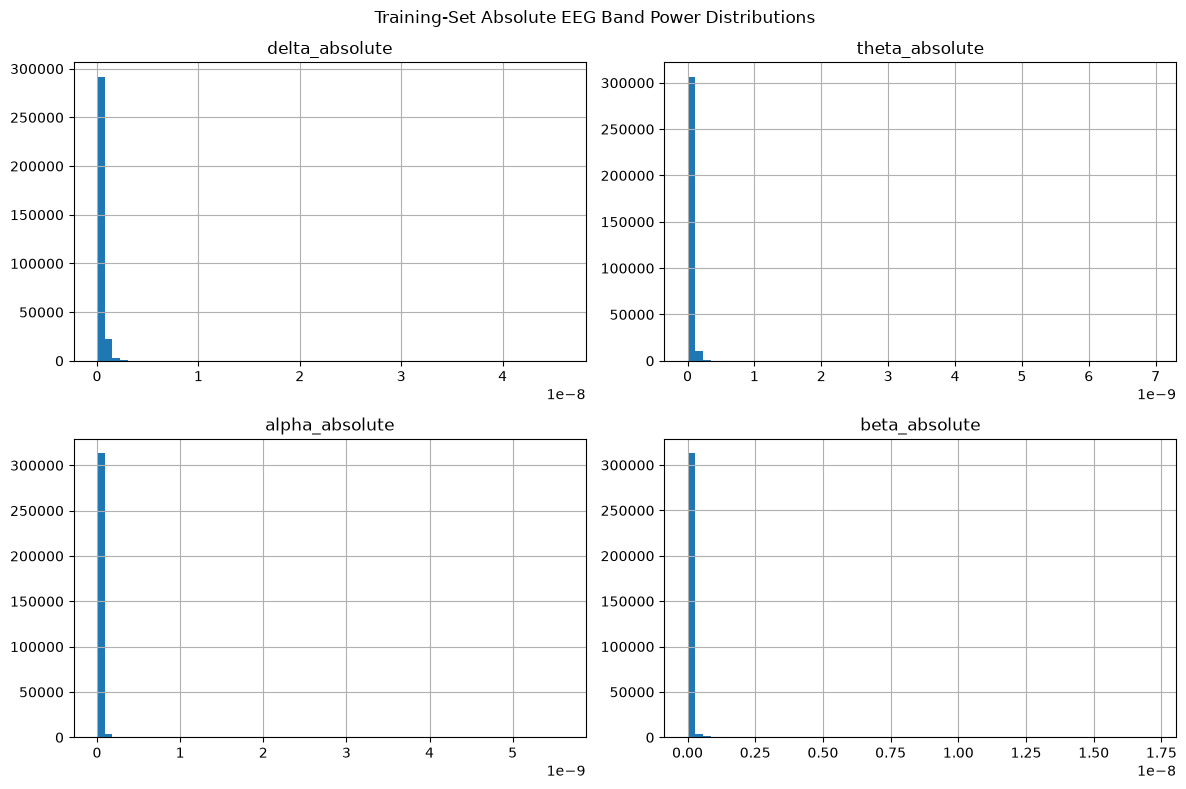

In [27]:
import matplotlib.pyplot as plt

absolute_power_columns = [
    "delta_absolute",
    "theta_absolute",
    "alpha_absolute",
    "beta_absolute",
]

train_df[
    absolute_power_columns
].hist(
    bins=60,
    figsize=(12, 8),
)

plt.suptitle(
    "Training-Set Absolute EEG Band Power Distributions"
)

plt.tight_layout()

plt.show()

**Log-scale distributions of absolute power**

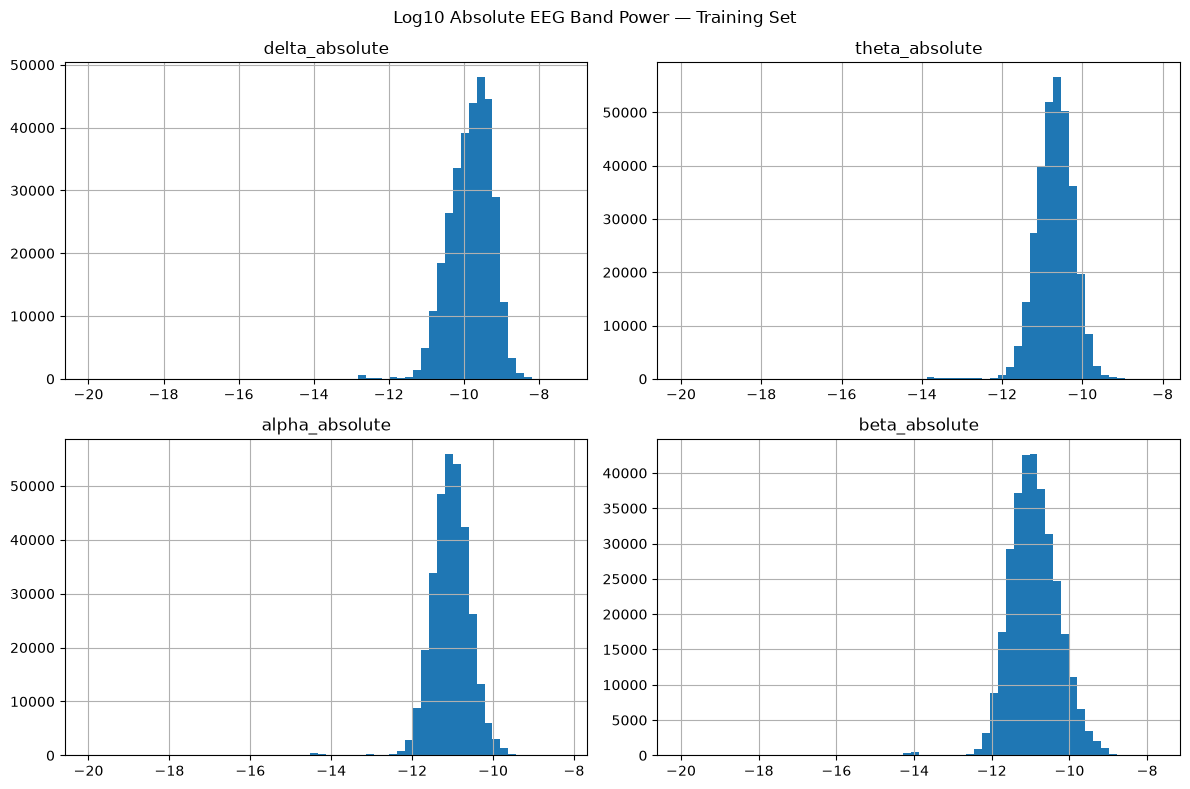

In [28]:
log_power_df = np.log10(
    train_df[
        absolute_power_columns
    ].clip(
        lower=1e-20
    )
)

log_power_df.hist(
    bins=60,
    figsize=(12, 8),
)

plt.suptitle(
    "Log10 Absolute EEG Band Power — Training Set"
)

plt.tight_layout()

plt.show()

**Statistics for relative power, entropy, and dominant frequency**

In [29]:
other_feature_columns = [
    "delta_relative",
    "theta_relative",
    "alpha_relative",
    "beta_relative",
    "spectral_entropy",
    "dominant_frequency",
]

display(
    train_df[
        other_feature_columns
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
delta_relative,318821.0,0.737320,0.165222,0.025375,0.658022,0.780997,0.859534,0.999502
theta_relative,318821.0,0.105787,0.050098,0.000485,0.071755,0.097669,0.129282,0.803068
alpha_relative,318821.0,0.058355,0.052337,0.000010,0.024190,0.042447,0.075110,0.776688
beta_relative,318821.0,0.098538,0.107702,0.000003,0.028136,0.059273,0.125879,0.878093
spectral_entropy,318821.0,0.716281,0.099210,0.231170,0.648899,0.709394,0.778890,0.986644
dominant_frequency,318821.0,1.000061,1.182759,0.585938,0.585938,0.781250,1.171875,29.980469


**Compare skewness before and after log transformation**

In [30]:
absolute_power_columns = [
    "delta_absolute",
    "theta_absolute",
    "alpha_absolute",
    "beta_absolute",
]

log_power_train = np.log10(
    train_df[absolute_power_columns]
)

comparison = pd.DataFrame({
    "raw_skewness": (
        train_df[
            absolute_power_columns
        ].skew()
    ),
    "log10_skewness": (
        log_power_train.skew()
    ),
})

print(
    comparison
)

                raw_skewness  log10_skewness
delta_absolute     14.280451      -14.409224
theta_absolute     40.828218      -19.931358
alpha_absolute     58.722623      -18.861978
beta_absolute      36.202920      -10.642818


In [31]:
from src.preprocessing.normalization import (
    SleepFeatureScaler,
    ALL_FEATURES,
    ABSOLUTE_POWER_FEATURES,
    STANDARD_FEATURES,
)

print("Normalization module imported successfully.")

Normalization module imported successfully.


**Fit the feature scaler using training data only**

In [32]:
feature_scaler = SleepFeatureScaler()

X_train_scaled = (
    feature_scaler.fit_transform(
        train_df
    )
)

print(
    "Scaled training shape:",
    X_train_scaled.shape
)

print(
    "\nTraining means after scaling:"
)

print(
    X_train_scaled.mean()
)

print(
    "\nTraining standard deviations after scaling:"
)

print(
    X_train_scaled.std()
)

Scaled training shape: (318821, 10)

Training means after scaling:
delta_absolute        1.551859e-15
theta_absolute        9.128580e-16
alpha_absolute        1.643144e-15
beta_absolute         8.415410e-16
delta_relative        7.987508e-17
theta_relative       -2.695784e-16
alpha_relative       -3.423218e-17
beta_relative         1.141073e-16
spectral_entropy      7.416971e-17
dominant_frequency   -4.047242e-17
dtype: float64

Training standard deviations after scaling:
delta_absolute        1.000002
theta_absolute        1.000002
alpha_absolute        1.000002
beta_absolute         1.000002
delta_relative        1.000002
theta_relative        1.000002
alpha_relative        1.000002
beta_relative         1.000002
spectral_entropy      1.000002
dominant_frequency    1.000002
dtype: float64


**Transform validation and test using the training scaler**

In [33]:
X_val_scaled = (
    feature_scaler.transform(
        val_df
    )
)

X_test_scaled = (
    feature_scaler.transform(
        test_df
    )
)

print(
    "Validation shape:",
    X_val_scaled.shape
)

print(
    "Test shape:",
    X_test_scaled.shape
)

Validation shape: (69567, 10)
Test shape: (68252, 10)


**Check scaled feature ranges**

In [34]:
scaled_train_df = pd.DataFrame(
    X_train_scaled,
    columns=ALL_FEATURES,
)

scaled_val_df = pd.DataFrame(
    X_val_scaled,
    columns=ALL_FEATURES,
)

scaled_test_df = pd.DataFrame(
    X_test_scaled,
    columns=ALL_FEATURES,
)

print("Training summary:")
display(
    scaled_train_df.describe().T[
        ["mean", "std", "min", "max"]
    ]
)

Training summary:


,mean,std,min,max
delta_absolute,1.551859e-15,1.000002,-54.563235,3.707295
theta_absolute,9.128580e-16,1.000002,-61.180917,4.286737
alpha_absolute,1.643144e-15,1.000002,-60.226038,4.695763
beta_absolute,8.415410e-16,1.000002,-49.843155,4.436331
delta_relative,7.987508e-17,1.000002,-4.309025,1.586852
theta_relative,-2.695784e-16,1.000002,-2.101946,13.918409
alpha_relative,-3.423218e-17,1.000002,-1.114785,13.725089
beta_relative,1.141073e-16,1.000002,-0.914889,7.238105
spectral_entropy,7.416971e-17,1.000002,-4.889772,2.725171
dominant_frequency,-4.047242e-17,1.000002,-0.350134,24.502420


**Verify scaler isolation**

In [35]:
print("Training scaled means:")
print(
    scaled_train_df.mean().round(6)
)

print("\nValidation scaled means:")
print(
    scaled_val_df.mean().round(6)
)

print("\nTest scaled means:")
print(
    scaled_test_df.mean().round(6)
)

Training scaled means:
delta_absolute        0.0
theta_absolute        0.0
alpha_absolute        0.0
beta_absolute         0.0
delta_relative        0.0
theta_relative       -0.0
alpha_relative       -0.0
beta_relative         0.0
spectral_entropy      0.0
dominant_frequency   -0.0
dtype: float64

Validation scaled means:
delta_absolute        0.061953
theta_absolute        0.080320
alpha_absolute        0.106025
beta_absolute         0.056430
delta_relative        0.023347
theta_relative        0.043217
alpha_relative        0.041507
beta_relative        -0.076089
spectral_entropy     -0.021178
dominant_frequency   -0.039081
dtype: float64

Test scaled means:
delta_absolute       -0.030371
theta_absolute       -0.045823
alpha_absolute       -0.057475
beta_absolute        -0.066817
delta_relative        0.069915
theta_relative        0.057159
alpha_relative       -0.049430
beta_relative        -0.109822
spectral_entropy     -0.026820
dominant_frequency   -0.038937
dtype: float64


**Investigate extremely small absolute-power values**

In [36]:
power_columns = [
    "delta_absolute",
    "theta_absolute",
    "alpha_absolute",
    "beta_absolute",
]

thresholds = [
    1e-20,
    1e-30,
    1e-35,
    1e-40,
    1e-45,
]

print("Number of training epochs below each power threshold:\n")

for threshold in thresholds:
    print(f"Threshold: {threshold:.0e}")

    for column in power_columns:
        count = (
            train_df[column] < threshold
        ).sum()

        print(
            f"  {column:>15}: {count:>6}"
        )

    print()

Number of training epochs below each power threshold:

Threshold: 1e-20
   delta_absolute:     47
   theta_absolute:     47
   alpha_absolute:     48
    beta_absolute:     48

Threshold: 1e-30
   delta_absolute:     46
   theta_absolute:     46
   alpha_absolute:     46
    beta_absolute:     46

Threshold: 1e-35
   delta_absolute:     46
   theta_absolute:     46
   alpha_absolute:     46
    beta_absolute:     46

Threshold: 1e-40
   delta_absolute:     24
   theta_absolute:     27
   alpha_absolute:     26
    beta_absolute:     20

Threshold: 1e-45
   delta_absolute:      5
   theta_absolute:      5
   alpha_absolute:      5
    beta_absolute:      5



**Examine total spectral power**

In [37]:
train_power = train_df[
    power_columns
].copy()

train_power["total_band_power"] = (
    train_power.sum(axis=1)
)

print(
    train_power[
        "total_band_power"
    ].describe(
        percentiles=[
            0.001,
            0.005,
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
            0.999,
        ]
    )
)

count    3.188210e+05
mean     3.864239e-10
std      5.199714e-10
min      1.307491e-46
0.1%     2.442849e-13
0.5%     6.810686e-12
1%       1.420650e-11
5%       3.197815e-11
25%      9.812993e-11
50%      2.345113e-10
75%      5.034385e-10
95%      1.204507e-09
99%      2.131506e-09
99.9%    5.072292e-09
max      5.290803e-08
Name: total_band_power, dtype: float64


**Identify epochs with extremely low total power**

In [38]:
train_power["subject_id"] = (
    train_df["subject_id"].to_numpy()
)

train_power["epoch_index"] = (
    train_df["epoch_index"].to_numpy()
)

suspicious_epochs = (
    train_power
    .sort_values(
        "total_band_power"
    )
    .head(20)
)

display(
    suspicious_epochs
)

,delta_absolute,theta_absolute,alpha_absolute,beta_absolute,total_band_power,subject_id,epoch_index
416787,4.617029e-47,1.440838e-47,1.398442e-47,5.618603e-47,1.307491e-46,ST7012,1036
416789,5.477073e-47,1.289540e-47,1.426207e-47,5.929155e-47,1.412198e-46,ST7012,1038
427430,4.940864e-47,1.707413e-47,1.481381e-47,6.063065e-47,1.419272e-46,ST7081,965
416790,5.121049e-47,2.321803e-47,4.437627e-47,7.401472e-47,1.928195e-46,ST7012,1039
416788,5.941404e-47,3.542200e-47,4.329924e-47,1.027785e-46,2.409138e-46,ST7012,1037
419630,7.230081e-42,1.710378e-42,1.250882e-42,3.808287e-42,1.399963e-41,ST7041,1001
419625,7.747214e-42,1.490137e-42,1.721972e-42,3.487448e-42,1.444677e-41,ST7041,996
419632,8.610159e-42,1.675567e-42,1.877721e-42,3.560506e-42,1.572395e-41,ST7041,1003
419635,7.404159e-42,1.912746e-42,1.511320e-42,5.087527e-42,1.591575e-41,ST7041,1006
419627,8.520786e-42,1.809834e-42,2.007826e-42,3.996347e-42,1.633479e-41,ST7041,998


**Extremely low power by sleep stage**

In [39]:
analysis_df = train_df.copy()

analysis_df["total_band_power"] = (
    analysis_df[
        power_columns
    ].sum(axis=1)
)

stage_power_summary = (
    analysis_df
    .groupby("target_stage")[
        "total_band_power"
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.50,
            0.95,
            0.99,
        ]
    )
)

display(
    stage_power_summary
)

,count,mean,std,min,1%,5%,50%,95%,99%,max
target_stage,,,,,,,,,,
N1,18653.0,1.043439e-10,1.516261e-10,3.559950e-40,1.037516e-11,1.780640e-11,6.349647e-11,3.015419e-10,6.943043e-10,4.198764e-09
N2,62097.0,1.892490e-10,3.603981e-10,1.399963e-41,1.743933e-11,3.510087e-11,1.354830e-10,4.913934e-10,9.587199e-10,5.290803e-08
N3,12882.0,6.891505e-10,6.368812e-10,1.729258e-11,9.095566e-11,1.657138e-10,4.884901e-10,2.038458e-09,3.253728e-09,8.066108e-09
REM,23737.0,9.917555e-11,1.293866e-10,1.841518e-40,7.768235e-12,1.821447e-11,6.679353e-11,2.635089e-10,5.944205e-10,3.291214e-09
W,201452.0,4.878093e-10,5.591118e-10,1.307491e-46,1.596567e-11,4.527207e-11,3.503148e-10,1.355812e-09,2.295222e-09,4.310476e-08


**Subjects with the most extremely low-power epochs**

In [40]:
very_low_power_mask = (
    analysis_df["total_band_power"]
    < 1e-20
)

low_power_by_subject = (
    analysis_df.loc[
        very_low_power_mask
    ]
    .groupby("subject_id")
    .size()
    .sort_values(
        ascending=False
    )
)

print(
    "Number of training epochs below 1e-20:",
    very_low_power_mask.sum()
)

print(
    "\nTop subjects by number of "
    "very-low-power epochs:"
)

display(
    low_power_by_subject.head(20)
)

Number of training epochs below 1e-20: 47

Top subjects by number of very-low-power epochs:


subject_id
ST7041    13
ST7241     6
ST7072     6
ST7172     5
ST7012     5
ST7051     4
ST7171     3
ST7151     2
ST7021     1
ST7081     1
ST7222     1
dtype: int64

**Recreate PSG/hypnogram pairings**

In [41]:
from src.data.pairing import build_recording_pairs

pairings = build_recording_pairs(
    PROJECT_ROOT / "data" / "raw"
)

print("Number of recording pairs:", len(pairings))
print(pairings.head())

Number of recording pairs: 197
  recording_id                                                psg  \
0       SC4001  D:\Local Disk\Uni Sources\Term 8\Final Project...   
1       SC4002  D:\Local Disk\Uni Sources\Term 8\Final Project...   
2       SC4011  D:\Local Disk\Uni Sources\Term 8\Final Project...   
3       SC4012  D:\Local Disk\Uni Sources\Term 8\Final Project...   
4       SC4021  D:\Local Disk\Uni Sources\Term 8\Final Project...   

                                           hypnogram  
0  D:\Local Disk\Uni Sources\Term 8\Final Project...  
1  D:\Local Disk\Uni Sources\Term 8\Final Project...  
2  D:\Local Disk\Uni Sources\Term 8\Final Project...  
3  D:\Local Disk\Uni Sources\Term 8\Final Project...  
4  D:\Local Disk\Uni Sources\Term 8\Final Project...  


**Inspect suspicious low-power EEG epochs**

ST7012 — epoch 1036
Time: 31080.0 to 31110.0 seconds
Stage: W
Min: -1.8311664530309967e-07
Max: -1.8311664530309967e-07
Mean: -1.8311664530309967e-07
Std: 0.0
RMS: 1.8311664530309967e-07


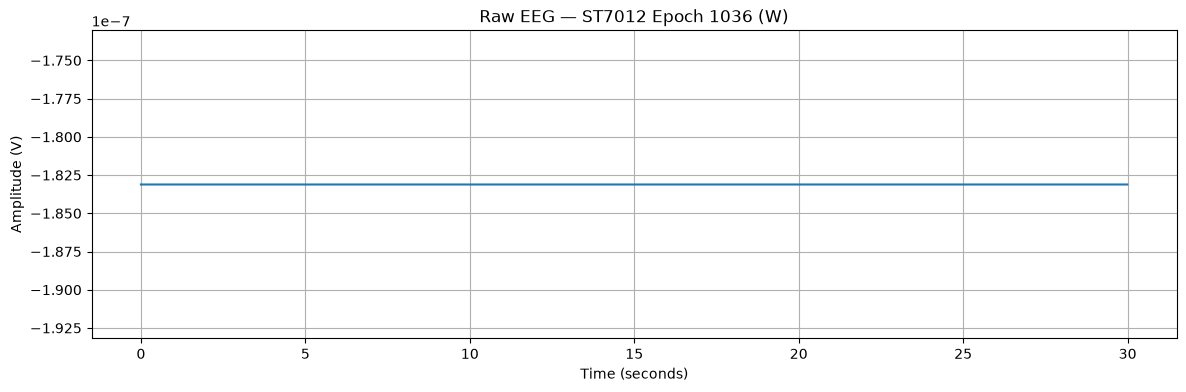

ST7041 — epoch 1001
Time: 30030.0 to 30060.0 seconds
Stage: N2
Min: -6.390770921076729e-05
Max: 0.00011554660318622958
Mean: 9.100531038271337e-06
Std: 2.6916332736970712e-05
RMS: 2.84131771047495e-05


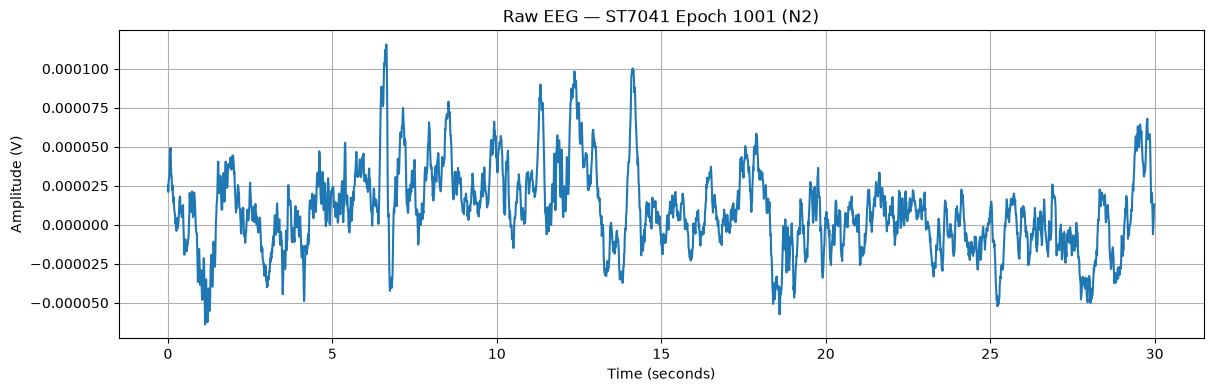

In [42]:
import mne
import numpy as np
import matplotlib.pyplot as plt

suspicious_examples = [
    ("ST7012", 1036),
    ("ST7041", 1001),
]

for subject_id, epoch_index in suspicious_examples:

    row = df[
        (df["subject_id"] == subject_id)
        & (df["epoch_index"] == epoch_index)
    ].iloc[0]

    subject_info = pairings[
        pairings["recording_id"] == subject_id
    ].iloc[0]

    print("=" * 70)
    print(f"{subject_id} — epoch {epoch_index}")
    print("=" * 70)

    print(
        "Time:",
        row["start_time"],
        "to",
        row["end_time"],
        "seconds",
    )

    print(
        "Stage:",
        row["target_stage"],
    )

    raw = mne.io.read_raw_edf(
        subject_info["psg"],
        include=["EEG Fpz-Cz"],
        preload=True,
        verbose=False,
    )

    sfreq = raw.info["sfreq"]

    start_sample = int(
        row["start_time"] * sfreq
    )

    end_sample = int(
        row["end_time"] * sfreq
    )

    signal = raw.get_data(
        start=start_sample,
        stop=end_sample,
    )[0]

    print(
        "Min:",
        signal.min(),
    )

    print(
        "Max:",
        signal.max(),
    )

    print(
        "Mean:",
        signal.mean(),
    )

    print(
        "Std:",
        signal.std(),
    )

    print(
        "RMS:",
        np.sqrt(
            np.mean(signal ** 2)
        ),
    )

    time = np.arange(
        len(signal)
    ) / sfreq

    plt.figure(
        figsize=(14, 4)
    )

    plt.plot(
        time,
        signal,
    )

    plt.xlabel(
        "Time (seconds)"
    )

    plt.ylabel(
        "Amplitude (V)"
    )

    plt.title(
        f"Raw EEG — {subject_id} "
        f"Epoch {epoch_index} "
        f"({row['target_stage']})"
    )

    plt.grid(True)

    plt.show()

**Quantify suspicious vs normal EEG amplitude**

In [43]:
comparison = [
    ("ST7012", 1036),   # suspicious
    ("ST7012", 1035),   # preceding epoch
    ("ST7041", 1001),   # suspicious
    ("ST7041", 1000),   # preceding epoch
]

for subject_id, epoch_index in comparison:

    row = df[
        (df["subject_id"] == subject_id)
        & (df["epoch_index"] == epoch_index)
    ].iloc[0]

    subject_info = pairings[
        pairings["recording_id"] == subject_id
    ].iloc[0]

    raw = mne.io.read_raw_edf(
        subject_info["psg"],
        include=["EEG Fpz-Cz"],
        preload=True,
        verbose=False,
    )

    sfreq = raw.info["sfreq"]

    start_sample = int(
        row["start_time"] * sfreq
    )

    end_sample = int(
        row["end_time"] * sfreq
    )

    signal = raw.get_data(
        start=start_sample,
        stop=end_sample,
    )[0]

    print(
        f"{subject_id} | "
        f"Epoch {epoch_index:4d} | "
        f"Stage {row['target_stage']:>3} | "
        f"Std = {signal.std():.6e} | "
        f"RMS = {np.sqrt(np.mean(signal ** 2)):.6e} | "
        f"Min = {signal.min():.6e} | "
        f"Max = {signal.max():.6e}"
    )

ST7012 | Epoch 1036 | Stage   W | Std = 0.000000e+00 | RMS = 1.831166e-07 | Min = -1.831166e-07 | Max = -1.831166e-07
ST7012 | Epoch 1035 | Stage   W | Std = 0.000000e+00 | RMS = 1.831166e-07 | Min = -1.831166e-07 | Max = -1.831166e-07
ST7041 | Epoch 1001 | Stage  N2 | Std = 2.691633e-05 | RMS = 2.841318e-05 | Min = -6.390771e-05 | Max = 1.155466e-04
ST7041 | Epoch 1000 | Stage  N2 | Std = 3.187674e-05 | RMS = 3.221222e-05 | Min = -9.906611e-05 | Max = 1.261674e-04


**Define a flat-epoch criterion**

In [44]:
FLAT_STD_THRESHOLD = 1e-10

print(
    "Initial flat-epoch standard deviation threshold:",
    FLAT_STD_THRESHOLD,
    "V"
)

Initial flat-epoch standard deviation threshold: 1e-10 V


**Test flat-epoch removal on ST7012**

In [45]:
from src.preprocessing.pipeline import (
    process_sleep_edf_subject,
)

st7012_row = pairings[
    pairings["recording_id"] == "ST7012"
].iloc[0]

st7012_test = process_sleep_edf_subject(
    psg_path=st7012_row["psg"],
    hypnogram_path=st7012_row["hypnogram"],
    recording_id="ST7012",
)

print(
    "ST7012 valid epochs after quality check:",
    len(st7012_test)
)

print(
    "\nDoes epoch 1036 remain?"
)

print(
    1036 in set(
        st7012_test[
            "epoch_index"
        ]
    )
)

ST7012 valid epochs after quality check: 1035

Does epoch 1036 remain?
False


**Verify ST7041 normal epochs remain**

In [46]:
st7041_row = pairings[
    pairings["recording_id"] == "ST7041"
].iloc[0]

st7041_test = process_sleep_edf_subject(
    psg_path=st7041_row["psg"],
    hypnogram_path=st7041_row["hypnogram"],
    recording_id="ST7041",
)

print(
    "ST7041 valid epochs:",
    len(st7041_test)
)

print(
    "\nDoes epoch 1001 remain?"
)

print(
    1001 in set(
        st7041_test[
            "epoch_index"
        ]
    )
)

ST7041 valid epochs: 1007

Does epoch 1001 remain?
True


In [47]:
st7012_row = pairings[
    pairings["recording_id"] == "ST7012"
].iloc[0]

st7012_test = process_sleep_edf_subject(
    psg_path=st7012_row["psg"],
    hypnogram_path=st7012_row["hypnogram"],
    recording_id="ST7012",
)

print("ST7012 shape:", st7012_test.shape)

print(
    "\nDoes epoch 1036 remain?"
)

print(
    1036 in set(
        st7012_test["epoch_index"]
    )
)

ST7012 shape: (1035, 16)

Does epoch 1036 remain?
False


In [48]:
st7041_row = pairings[
    pairings["recording_id"] == "ST7041"
].iloc[0]

st7041_test = process_sleep_edf_subject(
    psg_path=st7041_row["psg"],
    hypnogram_path=st7041_row["hypnogram"],
    recording_id="ST7041",
)

print("ST7041 shape:", st7041_test.shape)

print(
    "\nDoes epoch 1001 remain?"
)

print(
    1001 in set(
        st7041_test["epoch_index"]
    )
)

ST7041 shape: (1007, 16)

Does epoch 1001 remain?
True


In [49]:
sc4001_row = pairings[
    pairings["recording_id"] == "SC4001"
].iloc[0]

sc4001_test = process_sleep_edf_subject(
    psg_path=sc4001_row["psg"],
    hypnogram_path=sc4001_row["hypnogram"],
    recording_id="SC4001",
)

print("SC4001 shape:", sc4001_test.shape)

print("\nEpoch 1021:")
print(
    sc4001_test[
        sc4001_test["epoch_index"] == 1021
    ].T
)

SC4001 shape: (2650, 16)

Epoch 1021:
                             1021
subject_id                 SC4001
epoch_index                  1021
start_time                30630.0
end_time                  30660.0
raw_stage           Sleep stage 1
target_stage                   N1
delta_absolute                0.0
theta_absolute                0.0
alpha_absolute                0.0
beta_absolute                 0.0
delta_relative           0.520719
theta_relative           0.292891
alpha_relative           0.140492
beta_relative            0.045898
spectral_entropy          0.80624
dominant_frequency       1.171875


In [50]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent.resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.pairing import (
    build_recording_pairs,
)

from src.preprocessing.pipeline import (
    process_sleep_edf_subject,
)

pairings = build_recording_pairs(
    PROJECT_ROOT / "data" / "raw"
)

print(
    "Recording pairs:",
    len(pairings)
)

Recording pairs: 197


In [51]:
row = pairings[
    pairings["recording_id"] == "SC4001"
].iloc[0]

sc4001_test = process_sleep_edf_subject(
    psg_path=row["psg"],
    hypnogram_path=row["hypnogram"],
    recording_id="SC4001",
)

print(
    "SC4001:",
    sc4001_test.shape,
)

SC4001: (2650, 16)


In [52]:
row = pairings[
    pairings["recording_id"] == "ST7012"
].iloc[0]

st7012_test = process_sleep_edf_subject(
    psg_path=row["psg"],
    hypnogram_path=row["hypnogram"],
    recording_id="ST7012",
)

print(
    "ST7012:",
    st7012_test.shape,
)

print(
    "Epoch 1036 present:",
    1036 in set(
        st7012_test[
            "epoch_index"
        ]
    ),
)

ST7012: (1035, 16)
Epoch 1036 present: False


In [53]:
row = pairings[
    pairings["recording_id"] == "ST7041"
].iloc[0]

st7041_test = process_sleep_edf_subject(
    psg_path=row["psg"],
    hypnogram_path=row["hypnogram"],
    recording_id="ST7041",
)

print(
    "ST7041:",
    st7041_test.shape,
)

print(
    "Epoch 1001 present:",
    1001 in set(
        st7041_test[
            "epoch_index"
        ]
    ),
)

ST7041: (1007, 16)
Epoch 1001 present: True


**Compare old and new datasets**

In [54]:
from pathlib import Path
import pandas as pd

FEATURES_DIR = (
    PROJECT_ROOT
    / "data"
    / "features"
)

OLD_PATH = (
    FEATURES_DIR
    / "sleep_edf_features_before_quality_filter.csv"
)

NEW_PATH = (
    FEATURES_DIR
    / "sleep_edf_features.csv"
)

old_df = pd.read_csv(OLD_PATH)
new_df = pd.read_csv(NEW_PATH)

print("Old dataset:")
print("  Rows:", len(old_df))
print("  Subjects:", old_df["subject_id"].nunique())

print("\nNew dataset:")
print("  Rows:", len(new_df))
print("  Subjects:", new_df["subject_id"].nunique())

print("\nDifference:")
print(len(new_df) - len(old_df))

Old dataset:
  Rows: 456640
  Subjects: 197

New dataset:
  Rows: 457577
  Subjects: 197

Difference:
937


**Compare epoch counts per subject**

In [55]:
old_counts = (
    old_df
    .groupby("subject_id")
    .size()
    .rename("old_count")
)

new_counts = (
    new_df
    .groupby("subject_id")
    .size()
    .rename("new_count")
)

subject_comparison = pd.concat(
    [old_counts, new_counts],
    axis=1,
).fillna(0)

subject_comparison["old_count"] = (
    subject_comparison["old_count"].astype(int)
)

subject_comparison["new_count"] = (
    subject_comparison["new_count"].astype(int)
)

subject_comparison["difference"] = (
    subject_comparison["new_count"]
    - subject_comparison["old_count"]
)

print(
    "Subjects with changed epoch counts:"
)

display(
    subject_comparison[
        subject_comparison["difference"] != 0
    ]
    .sort_values(
        "difference",
        ascending=False,
    )
)

Subjects with changed epoch counts:


,old_count,new_count,difference
subject_id,,,
ST7151,671,891,220
SC4762,2514,2662,148
ST7191,883,955,72
ST7182,901,967,66
ST7201,872,921,49
...,...,...,...
ST7071,820,816,-4
ST7152,1045,1041,-4
ST7012,1040,1035,-5


**Largest subject-level differences**

In [56]:
display(
    subject_comparison
    .sort_values(
        "difference",
        ascending=False,
    )
    .head(20)
)

print(
    "\nTotal increase across subjects:",
    subject_comparison[
        "difference"
    ]
    .clip(lower=0)
    .sum(),
)

print(
    "Total decrease across subjects:",
    -subject_comparison[
        "difference"
    ]
    .clip(upper=0)
    .sum(),
)

,old_count,new_count,difference
subject_id,,,
ST7151,671,891,220
SC4762,2514,2662,148
ST7191,883,955,72
ST7182,901,967,66
ST7201,872,921,49
ST7202,854,897,43
ST7242,899,939,40
ST7241,984,1015,31
ST7122,921,945,24



Total increase across subjects: 974
Total decrease across subjects: 37


**Inspect one subject with a changed count**

In [57]:
changed_subjects = subject_comparison[
    subject_comparison["difference"] != 0
].index.tolist()

print(
    "Number of subjects with changed counts:",
    len(changed_subjects)
)

if changed_subjects:
    subject_id = changed_subjects[0]

    print(
        "\nInspecting:",
        subject_id
    )

    old_subject = (
        old_df[
            old_df["subject_id"] == subject_id
        ]
        .sort_values("epoch_index")
    )

    new_subject = (
        new_df[
            new_df["subject_id"] == subject_id
        ]
        .sort_values("epoch_index")
    )

    print(
        "\nOld count:",
        len(old_subject)
    )

    print(
        "New count:",
        len(new_subject)
    )

    print(
        "\nOld first/last epochs:"
    )

    display(
        old_subject[
            [
                "epoch_index",
                "start_time",
                "end_time",
                "raw_stage",
                "target_stage",
            ]
        ].head(5)
    )

    display(
        old_subject[
            [
                "epoch_index",
                "start_time",
                "end_time",
                "raw_stage",
                "target_stage",
            ]
        ].tail(5)
    )

    print(
        "\nNew first/last epochs:"
    )

    display(
        new_subject[
            [
                "epoch_index",
                "start_time",
                "end_time",
                "raw_stage",
                "target_stage",
            ]
        ].head(5)
    )

    display(
        new_subject[
            [
                "epoch_index",
                "start_time",
                "end_time",
                "raw_stage",
                "target_stage",
            ]
        ].tail(5)
    )

Number of subjects with changed counts: 88

Inspecting: SC4002

Old count: 2828
New count: 2829

Old first/last epochs:


,epoch_index,start_time,end_time,raw_stage,target_stage
2650,0,0.0,30.0,Sleep stage W,W
2651,1,30.0,60.0,Sleep stage W,W
2652,2,60.0,90.0,Sleep stage W,W
2653,3,90.0,120.0,Sleep stage W,W
2654,4,120.0,150.0,Sleep stage W,W


,epoch_index,start_time,end_time,raw_stage,target_stage
5473,2824,84720.0,84750.0,Sleep stage W,W
5474,2825,84750.0,84780.0,Sleep stage W,W
5475,2826,84780.0,84810.0,Sleep stage W,W
5476,2827,84810.0,84840.0,Sleep stage W,W
5477,2828,84840.0,84870.0,Sleep stage W,W



New first/last epochs:


,epoch_index,start_time,end_time,raw_stage,target_stage
2650,0,0.0,30.0,Sleep stage W,W
2651,1,30.0,60.0,Sleep stage W,W
2652,2,60.0,90.0,Sleep stage W,W
2653,3,90.0,120.0,Sleep stage W,W
2654,4,120.0,150.0,Sleep stage W,W


,epoch_index,start_time,end_time,raw_stage,target_stage
5474,2825,84750.0,84780.0,Sleep stage W,W
5475,2826,84780.0,84810.0,Sleep stage W,W
5476,2827,84810.0,84840.0,Sleep stage W,W
5477,2828,84840.0,84870.0,Sleep stage W,W
5478,2829,84870.0,84900.0,Sleep stage W,W


In [58]:
from src.data.pairing import build_recording_pairs
from src.preprocessing.pipeline import (
    process_sleep_edf_subject,
)

pairings = build_recording_pairs(
    PROJECT_ROOT / "data" / "raw"
)

row = pairings[
    pairings["recording_id"] == "SC4002"
].iloc[0]

sc4002_fixed = process_sleep_edf_subject(
    psg_path=row["psg"],
    hypnogram_path=row["hypnogram"],
    recording_id="SC4002",
)

print(
    "SC4002 shape:",
    sc4002_fixed.shape,
)

print(
    "\nEpoch 936 present:",
    936 in set(
        sc4002_fixed[
            "epoch_index"
        ]
    )
)

print(
    "\nLast 10 epochs:"
)

print(
    sc4002_fixed[
        [
            "epoch_index",
            "start_time",
            "end_time",
            "raw_stage",
            "target_stage",
        ]
    ].tail(10)
)

SC4002 shape: (2829, 16)

Epoch 936 present: True

Last 10 epochs:
      epoch_index  start_time  end_time      raw_stage target_stage
2819         2819     84600.0   84630.0  Sleep stage W            W
2820         2820     84630.0   84660.0  Sleep stage W            W
2821         2821     84660.0   84690.0  Sleep stage W            W
2822         2822     84690.0   84720.0  Sleep stage W            W
2823         2823     84720.0   84750.0  Sleep stage W            W
2824         2824     84750.0   84780.0  Sleep stage W            W
2825         2825     84780.0   84810.0  Sleep stage W            W
2826         2826     84810.0   84840.0  Sleep stage W            W
2827         2827     84840.0   84870.0  Sleep stage W            W
2828         2828     84870.0   84900.0  Sleep stage W            W


In [59]:
row = pairings[
    pairings["recording_id"] == "ST7012"
].iloc[0]

st7012_fixed = process_sleep_edf_subject(
    psg_path=row["psg"],
    hypnogram_path=row["hypnogram"],
    recording_id="ST7012",
)

print(
    "ST7012 shape:",
    st7012_fixed.shape,
)

print(
    "Epoch 1036 present:",
    1036 in set(
        st7012_fixed[
            "epoch_index"
        ]
    ),
)

ST7012 shape: (1035, 16)
Epoch 1036 present: False


In [60]:
row = pairings[
    pairings["recording_id"] == "ST7041"
].iloc[0]

st7041_fixed = process_sleep_edf_subject(
    psg_path=row["psg"],
    hypnogram_path=row["hypnogram"],
    recording_id="ST7041",
)

print(
    "ST7041 shape:",
    st7041_fixed.shape,
)

print(
    "Epoch 1001 present:",
    1001 in set(
        st7041_fixed[
            "epoch_index"
        ]
    ),
)

ST7041 shape: (1007, 16)
Epoch 1001 present: True


**Verify the SC4002 Movement-time boundary**

In [61]:
sc4002_epoch_936 = sc4002_fixed[
    sc4002_fixed["epoch_index"] == 936
]

print(sc4002_epoch_936[
    [
        "epoch_index",
        "start_time",
        "end_time",
        "raw_stage",
        "target_stage",
    ]
])

print("\nPrevious epoch:")
print(
    sc4002_fixed[
        sc4002_fixed["epoch_index"] == 935
    ][
        [
            "epoch_index",
            "start_time",
            "end_time",
            "raw_stage",
            "target_stage",
        ]
    ]
)

print("\nNext epoch:")
print(
    sc4002_fixed[
        sc4002_fixed["epoch_index"] == 937
    ][
        [
            "epoch_index",
            "start_time",
            "end_time",
            "raw_stage",
            "target_stage",
        ]
    ]
)

     epoch_index  start_time  end_time      raw_stage target_stage
936          936     28110.0   28140.0  Sleep stage 3           N3

Previous epoch:
     epoch_index  start_time  end_time      raw_stage target_stage
935          935     28050.0   28080.0  Sleep stage 4           N3

Next epoch:
     epoch_index  start_time  end_time      raw_stage target_stage
937          937     28140.0   28170.0  Sleep stage 3           N3


**Independent annotation-count verification for SC4002**

In [62]:
import mne
import numpy as np

sc4002_annotations = mne.read_annotations(
    pairings[
        pairings["recording_id"] == "SC4002"
    ].iloc[0]["hypnogram"]
)

valid_stage_names = {
    "Sleep stage W",
    "Sleep stage 1",
    "Sleep stage 2",
    "Sleep stage 3",
    "Sleep stage 4",
    "Sleep stage R",
}

annotation_epoch_count = 0

for duration, description in zip(
    sc4002_annotations.duration,
    sc4002_annotations.description,
):
    if description in valid_stage_names:
        annotation_epoch_count += int(
            np.floor(
                duration / 30.0
            )
        )

print(
    "Epochs implied directly by valid annotations:",
    annotation_epoch_count,
)

print(
    "Epochs produced by current pipeline:",
    len(sc4002_fixed),
)

Epochs implied directly by valid annotations: 2829
Epochs produced by current pipeline: 2829


**Load the final feature dataset**

In [63]:
FEATURES_PATH = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "sleep_edf_features.csv"
)

df = pd.read_csv(
    FEATURES_PATH
)

print("Shape:", df.shape)

print(
    "Subjects:",
    df["subject_id"].nunique()
)

print(
    "\nClass distribution:"
)

print(
    df["target_stage"].value_counts()
)

Shape: (457577, 16)
Subjects: 197

Class distribution:
target_stage
W      289781
N2      88983
REM     34184
N1      25175
N3      19454
Name: count, dtype: int64


**Apply the frozen subject split**

In [64]:
SPLIT_PATH = (
    PROJECT_ROOT
    / "data"
    / "features"
    / "subject_split.csv"
)

split_df = pd.read_csv(
    SPLIT_PATH
)

df_with_split = df.merge(
    split_df,
    on="subject_id",
    how="inner",
    validate="many_to_one",
)

train_df = df_with_split[
    df_with_split["split"] == "train"
].copy()

val_df = df_with_split[
    df_with_split["split"] == "val"
].copy()

test_df = df_with_split[
    df_with_split["split"] == "test"
].copy()

print("Train:")
print(
    len(train_df),
    "epochs /",
    train_df["subject_id"].nunique(),
    "subjects"
)

print("\nValidation:")
print(
    len(val_df),
    "epochs /",
    val_df["subject_id"].nunique(),
    "subjects"
)

print("\nTest:")
print(
    len(test_df),
    "epochs /",
    test_df["subject_id"].nunique(),
    "subjects"
)

Train:
319628 epochs / 138 subjects

Validation:
69602 epochs / 30 subjects

Test:
68347 epochs / 29 subjects


**Class distribution after final preprocessing**

In [65]:
stage_order = [
    "W",
    "N1",
    "N2",
    "N3",
    "REM",
]

split_stage_counts = (
    df_with_split
    .groupby(
        ["split", "target_stage"]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reindex(
        columns=stage_order,
        fill_value=0,
    )
)

split_stage_percentages = (
    split_stage_counts.div(
        split_stage_counts.sum(axis=1),
        axis=0,
    )
    * 100
)

print("Epoch counts:")
display(split_stage_counts)

print("\nPercentages:")
display(
    split_stage_percentages.round(2)
)

Epoch counts:


target_stage,W,N1,N2,N3,REM
split,,,,,
test,43636,3005,13557,2864,5285
train,201735,18732,62429,12907,23825
val,44410,3438,12997,3683,5074



Percentages:


target_stage,W,N1,N2,N3,REM
split,,,,,
test,63.84,4.40,19.84,4.19,7.73
train,63.12,5.86,19.53,4.04,7.45
val,63.81,4.94,18.67,5.29,7.29


**Check extremely low total spectral power**

In [66]:
power_columns = [
    "delta_absolute",
    "theta_absolute",
    "alpha_absolute",
    "beta_absolute",
]

df["total_band_power"] = (
    df[power_columns].sum(axis=1)
)

very_low = (
    df["total_band_power"]
    < 1e-20
)

print(
    "Epochs with total band power < 1e-20:"
)

print(
    very_low.sum()
)

print(
    "\nPercentage:"
)

print(
    very_low.mean() * 100
)

Epochs with total band power < 1e-20:
0

Percentage:
0.0


**Fit the final scaler on training subjects only**

In [67]:
from src.preprocessing.normalization import (
    SleepFeatureScaler,
    ALL_FEATURES,
)

feature_scaler = SleepFeatureScaler()

X_train_scaled = (
    feature_scaler.fit_transform(
        train_df
    )
)

X_val_scaled = (
    feature_scaler.transform(
        val_df
    )
)

X_test_scaled = (
    feature_scaler.transform(
        test_df
    )
)

print(
    "Train scaled shape:",
    X_train_scaled.shape
)

print(
    "Validation scaled shape:",
    X_val_scaled.shape
)

print(
    "Test scaled shape:",
    X_test_scaled.shape
)

Train scaled shape: (319628, 10)
Validation scaled shape: (69602, 10)
Test scaled shape: (68347, 10)


In [68]:
from src.preprocessing.sequences import (
    find_contiguous_runs,
)

sc4002_df = df_with_split[
    df_with_split["subject_id"] == "SC4002"
].copy()

runs = find_contiguous_runs(
    sc4002_df
)

print(
    "Number of contiguous runs:",
    len(runs)
)

for i, run in enumerate(runs):
    print(
        f"Run {i}: "
        f"{len(run)} epochs | "
        f"{run['start_time'].iloc[0]}s → "
        f"{run['end_time'].iloc[-1]}s"
    )

Number of contiguous runs: 2
Run 0: 936 epochs | 0.0s → 28080.0s
Run 1: 1893 epochs | 28110.0s → 84900.0s


**Inspect the runs around the known SC4002 gap**

In [69]:
for i, run in enumerate(runs):

    contains_boundary = (
        (
            run["start_time"]
            <= 28080.0
        )
        &
        (
            run["end_time"]
            >= 28110.0
        )
    ).any()

    if contains_boundary:

        print(
            "Run containing the boundary:"
        )

        print(
            run[
                [
                    "epoch_index",
                    "start_time",
                    "end_time",
                    "target_stage",
                ]
            ].head()
        )

        print("...")

        print(
            run[
                [
                    "epoch_index",
                    "start_time",
                    "end_time",
                    "target_stage",
                ]
            ].tail()
        )

In [70]:
from src.preprocessing.sequences import (
    build_sequences_from_dataframe,
)

# Ensure the dataframes are in a deterministic order.
train_df = train_df.sort_values(
    ["subject_id", "start_time"]
).reset_index(drop=True)

val_df = val_df.sort_values(
    ["subject_id", "start_time"]
).reset_index(drop=True)

test_df = test_df.sort_values(
    ["subject_id", "start_time"]
).reset_index(drop=True)

**Recreate normalized matrices in deterministic order**

In [71]:
feature_scaler = SleepFeatureScaler()

X_train_scaled = (
    feature_scaler.fit_transform(
        train_df
    )
)

X_val_scaled = (
    feature_scaler.transform(
        val_df
    )
)

X_test_scaled = (
    feature_scaler.transform(
        test_df
    )
)

print(
    "Train:",
    X_train_scaled.shape
)

print(
    "Validation:",
    X_val_scaled.shape
)

print(
    "Test:",
    X_test_scaled.shape
)

Train: (319628, 10)
Validation: (69602, 10)
Test: (68347, 10)


**Build baseline LSTM sequences**

In [72]:
SEQUENCE_LENGTH = 10

X_train_seq, y_train_seq = (
    build_sequences_from_dataframe(
        dataframe=train_df,
        feature_values=X_train_scaled,
        sequence_length=SEQUENCE_LENGTH,
    )
)

X_val_seq, y_val_seq = (
    build_sequences_from_dataframe(
        dataframe=val_df,
        feature_values=X_val_scaled,
        sequence_length=SEQUENCE_LENGTH,
    )
)

X_test_seq, y_test_seq = (
    build_sequences_from_dataframe(
        dataframe=test_df,
        feature_values=X_test_scaled,
        sequence_length=SEQUENCE_LENGTH,
    )
)

print(
    "Training sequences:",
    X_train_seq.shape
)

print(
    "Validation sequences:",
    X_val_seq.shape
)

print(
    "Test sequences:",
    X_test_seq.shape
)

Training sequences: (317000, 10, 10)
Validation sequences: (69188, 10, 10)
Test sequences: (67710, 10, 10)


**Check sequence target distribution**

In [73]:
print("Training target distribution:")
print(
    pd.Series(y_train_seq)
    .value_counts()
)

print(
    "\nValidation target distribution:"
)

print(
    pd.Series(y_val_seq)
    .value_counts()
)

print(
    "\nTest target distribution:"
)

print(
    pd.Series(y_test_seq)
    .value_counts()
)

Training target distribution:
W      247536
N2      26534
N3      23495
REM     13257
N1       6178
Name: count, dtype: int64

Validation target distribution:
W      46641
N2      8814
N3      7368
REM     4990
N1      1375
Name: count, dtype: int64

Test target distribution:
W      48833
N2     11286
REM     4748
N1      1466
N3      1377
Name: count, dtype: int64


**Sequence target distribution percentages**

In [74]:
for split_name, targets in [
    ("Train", y_train_seq),
    ("Validation", y_val_seq),
    ("Test", y_test_seq),
]:
    counts = (
        pd.Series(targets)
        .value_counts()
        .reindex(
            ["W", "N1", "N2", "N3", "REM"],
            fill_value=0,
        )
    )

    percentages = (
        counts / counts.sum() * 100
    )

    print(f"\n{split_name}")
    print("-" * 40)
    print(
        pd.DataFrame({
            "count": counts,
            "percentage": percentages.round(2),
        })
    )


Train
----------------------------------------
      count  percentage
W    247536       78.09
N1     6178        1.95
N2    26534        8.37
N3    23495        7.41
REM   13257        4.18

Validation
----------------------------------------
     count  percentage
W    46641       67.41
N1    1375        1.99
N2    8814       12.74
N3    7368       10.65
REM   4990        7.21

Test
----------------------------------------
     count  percentage
W    48833       72.12
N1    1466        2.17
N2   11286       16.67
N3    1377        2.03
REM   4748        7.01


**Verify subject isolation of sequence construction**

In [75]:
def count_possible_cross_subject_windows(
    dataframe,
    sequence_length,
):
    """
    Verify that no sequence could cross a subject boundary.
    """

    total_crossings = 0

    for _, group in dataframe.groupby(
        "subject_id",
        sort=False,
    ):
        n = len(group)

        total_crossings += max(
            0,
            n - sequence_length + 1,
        )

    return total_crossings


print(
    "Training subjects:",
    train_df["subject_id"].nunique(),
)

print(
    "Validation subjects:",
    val_df["subject_id"].nunique(),
)

print(
    "Test subjects:",
    test_df["subject_id"].nunique(),
)

Training subjects: 138
Validation subjects: 30
Test subjects: 29


**Inspect the first training sequence (window)**

In [76]:
first_sequence = X_train_seq[0]
first_target = y_train_seq[0]

print(
    "Sequence shape:",
    first_sequence.shape,
)

print(
    "Target:",
    first_target,
)

print(
    "\nFirst sequence feature values:"
)

print(first_sequence)

Sequence shape: (10, 10)
Target: W

First sequence feature values:
[[ 0.827253    1.4655058  -0.01283447 -0.14284359  0.3186156   1.4005444
  -0.80907357 -0.7474652  -0.4918627  -0.35112542]
 [ 0.4107729   0.6651932   0.35377437  0.61183476  0.10194154  0.3118094
  -0.3702394  -0.12149056  0.39693853  0.06366992]
 [ 0.7020605   0.15007769  0.29391846  0.24581994  0.83156973 -1.0018017
  -0.55892265 -0.5377336  -1.1221302   0.14662899]
 [ 0.21894747 -0.10387293  0.35072944 -0.34142187  0.6072701  -0.6051671
  -0.05971649 -0.6211098  -0.5981496   0.5614243 ]
 [-0.15075374  0.7281457   0.07889616 -0.4648348  -0.3873975   2.659991
  -0.1000608  -0.595429   -0.01128551  0.8932606 ]
 [ 0.6636342   1.3775312   0.03406975 -0.31611273  0.19808254  1.7333435
  -0.72757375 -0.757113   -0.0747481   0.22958805]
 [ 0.9629395   1.1966982   0.7336748   1.0315462   0.2692812   0.0741448
  -0.54079986 -0.18464057  0.02824297 -0.35112542]
 [ 0.87711746  0.9624399  -0.21008301 -0.15324986  0.76413584 -0.0

**Validate target alignment for a sequence (the sequence target corresponds to the last epoch)**

In [77]:
def inspect_first_sequence_source(
    dataframe,
    sequence_length=10,
):
    """
    Show the first valid sequence source rows.
    """

    for subject_id, subject_df in (
        dataframe
        .groupby("subject_id", sort=False)
    ):

        runs = find_contiguous_runs(
            subject_df
        )

        for run in runs:

            if len(run) >= sequence_length:

                source = run.iloc[
                    :sequence_length
                ]

                print(
                    "Subject:",
                    subject_id,
                )

                print(
                    source[
                        [
                            "epoch_index",
                            "start_time",
                            "end_time",
                            "target_stage",
                        ]
                    ]
                )

                print(
                    "\nExpected target:",
                    source[
                        "target_stage"
                    ].iloc[-1],
                )

                return


inspect_first_sequence_source(
    train_df,
    sequence_length=SEQUENCE_LENGTH,
)

Subject: SC4001
   epoch_index  start_time  end_time target_stage
0            0         0.0      30.0            W
1            1        30.0      60.0            W
2            2        60.0      90.0            W
3            3        90.0     120.0            W
4            4       120.0     150.0            W
5            5       150.0     180.0            W
6            6       180.0     210.0            W
7            7       210.0     240.0            W
8            8       240.0     270.0            W
9            9       270.0     300.0            W

Expected target: W


**Compare candidate sequence lengths**

In [78]:
candidate_lengths = [5, 10, 20]

for length in candidate_lengths:

    print("\n" + "=" * 60)
    print(
        f"Sequence length: {length} "
        f"epochs ({length * 30 / 60:.1f} minutes)"
    )
    print("=" * 60)

    _, train_targets = (
        build_sequences_from_dataframe(
            dataframe=train_df,
            feature_values=X_train_scaled,
            sequence_length=length,
        )
    )

    _, val_targets = (
        build_sequences_from_dataframe(
            dataframe=val_df,
            feature_values=X_val_scaled,
            sequence_length=length,
        )
    )

    _, test_targets = (
        build_sequences_from_dataframe(
            dataframe=test_df,
            feature_values=X_test_scaled,
            sequence_length=length,
        )
    )

    print(
        "Train sequences:",
        len(train_targets),
    )

    print(
        "Validation sequences:",
        len(val_targets),
    )

    print(
        "Test sequences:",
        len(test_targets),
    )

    print(
        "\nTrain target percentages:"
    )

    train_percentage = (
        pd.Series(train_targets)
        .value_counts(
            normalize=True
        )
        .reindex(
            ["W", "N1", "N2", "N3", "REM"],
            fill_value=0,
        )
        * 100
    )

    print(
        train_percentage.round(2)
    )


Sequence length: 5 epochs (2.5 minutes)
Train sequences: 318437
Validation sequences: 69418
Test sequences: 68062

Train target percentages:
W      78.09
N1      1.95
N2      8.38
N3      7.40
REM     4.18
Name: proportion, dtype: float64

Sequence length: 10 epochs (5.0 minutes)
Train sequences: 317000
Validation sequences: 69188
Test sequences: 67710

Train target percentages:
W      78.09
N1      1.95
N2      8.37
N3      7.41
REM     4.18
Name: proportion, dtype: float64

Sequence length: 20 epochs (10.0 minutes)
Train sequences: 314291
Validation sequences: 68730
Test sequences: 67017

Train target percentages:
W      78.07
N1      1.95
N2      8.36
N3      7.44
REM     4.18
Name: proportion, dtype: float64


In [79]:
from src.preprocessing.sequences import (
    find_contiguous_runs,
    build_sequences_from_dataframe,
    encode_sleep_stage_labels,
    CLASS_LABELS,
    CLASS_TO_INDEX,
)

print(
    "Sequence module imported successfully."
)

print(
    "Class mapping:",
    CLASS_TO_INDEX,
)

Sequence module imported successfully.
Class mapping: {'W': 0, 'N1': 1, 'N2': 2, 'N3': 3, 'REM': 4}


**Encode sleep-stage sequence targets**

In [ ]:
from src.preprocessing.sequences import (
    encode_sleep_stage_labels,
)

y_train = encode_sleep_stage_labels(
    y_train_seq
)

y_val = encode_sleep_stage_labels(
    y_val_seq
)

y_test = encode_sleep_stage_labels(
    y_test_seq
)

print("Class mapping:")
print({
    "W": 0,
    "N1": 1,
    "N2": 2,
    "N3": 3,
    "REM": 4,
})

print(
    "\nTraining label shape:",
    y_train.shape,
)

print(
    "Validation label shape:",
    y_val.shape,
)

print(
    "Test label shape:",
    y_test.shape,
)

Class mapping:
{'W': 0, 'N1': 1, 'N2': 2, 'N3': 3, 'REM': 4}

Training label shape: (317000,)
Validation label shape: (69188,)
Test label shape: (67710,)


**Calculate training class weights**

In [81]:
from sklearn.utils.class_weight import compute_class_weight
from src.preprocessing.sequences import (
    CLASS_LABELS,
    CLASS_TO_INDEX,
)

class_indices = np.arange(
    len(
        CLASS_TO_INDEX
    )
)

class_weights_array = (
    compute_class_weight(
        class_weight="balanced",
        classes=class_indices,
        y=y_train,
    )
)

class_weights = {
    int(class_index): float(weight)
    for class_index, weight
    in zip(
        class_indices,
        class_weights_array,
    )
}

print("Class weights:")

for class_index, weight in class_weights.items():
    label = CLASS_LABELS[
        class_index
    ]

    print(
        f"{label:>3} "
        f"(class {class_index}): "
        f"{weight:.4f}"
    )

Class weights:
  W (class 0): 0.2561
 N1 (class 1): 10.2622
 N2 (class 2): 2.3894
 N3 (class 3): 2.6984
REM (class 4): 4.7824


**Baseline experiment configuration**

In [82]:
BASELINE_CONFIG = {
    "sequence_length": 10,
    "sequence_duration_minutes": 5.0,
    "n_features": 10,
    "n_classes": 5,
    "eeg_channel": "EEG Fpz-Cz",
    "sampling_frequency": 100.0,
    "filter_low_hz": 0.3,
    "filter_high_hz": 35.0,
    "analysis_low_hz": 0.5,
    "analysis_high_hz": 30.0,
    "random_seed": 42,
}

print(BASELINE_CONFIG)

{'sequence_length': 10, 'sequence_duration_minutes': 5.0, 'n_features': 10, 'n_classes': 5, 'eeg_channel': 'EEG Fpz-Cz', 'sampling_frequency': 100.0, 'filter_low_hz': 0.3, 'filter_high_hz': 35.0, 'analysis_low_hz': 0.5, 'analysis_high_hz': 30.0, 'random_seed': 42}


**Make sure TensorFlow is available**

In [83]:
import tensorflow as tf

print(
    "TensorFlow version:",
    tf.__version__,
)

print(
    "Available GPUs:",
    tf.config.list_physical_devices(
        "GPU"
    ),
)

TensorFlow version: 2.21.0
Available GPUs: []


In [84]:
from src.models.lstm import (
    build_baseline_lstm,
    compile_baseline_lstm,
)

model = build_baseline_lstm(
    sequence_length=10,
    n_features=10,
    n_classes=5,
    lstm_units=64,
    dropout_rate=0.30,
)

model = compile_baseline_lstm(
    model,
    learning_rate=1e-3,
)

model.summary()

Model: "baseline_sleep_stage_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_features (InputLayer)       │ (None, 10, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sleep_stage (Dense)             │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,525 (76.27 KB)

 Trainable params: 19,525 (76.27 KB)

 Non-trainable params: 0 (0.00 B)

**Add reproducibility seeds**

In [85]:
import random
import numpy as np
import tensorflow as tf

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seeds set to:", SEED)

Random seeds set to: 42


**Prepare TensorFlow datasets**

In [86]:
BATCH_SIZE = 256

train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_train_seq,
            y_train,
        )
    )
    .shuffle(
        buffer_size=10000,
        seed=SEED,
        reshuffle_each_iteration=True,
    )
    .batch(
        BATCH_SIZE
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)

val_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_val_seq,
            y_val,
        )
    )
    .batch(
        BATCH_SIZE
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)

test_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_test_seq,
            y_test,
        )
    )
    .batch(
        BATCH_SIZE
    )
    .prefetch(
        tf.data.AUTOTUNE
    )
)

print("Datasets created.")

Datasets created.


**Train with class-weighted loss**

In [87]:
from tensorflow import keras

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    ),
]

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/30


d:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1239/1239 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.9432 - loss: 0.2573 - val_accuracy: 0.8484 - val_loss: 0.5346 - learning_rate: 0.0010
Epoch 2/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.9856 - loss: 0.0519 - val_accuracy: 0.8605 - val_loss: 0.7235 - learning_rate: 0.0010
Epoch 3/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9952 - loss: 0.0140 - val_accuracy: 0.8435 - val_loss: 0.7376 - learning_rate: 0.0010
Epoch 4/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9975 - loss: 0.0061 - val_accuracy: 0.8621 - val_loss: 0.7835 - learning_rate: 5.0000e-04
Epoch 5/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.9975 - loss: 0.0070 - val_accuracy: 0.8491 - val_loss: 0.8693 - learning_rate: 5.0000e-04
Epoch 6/30
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9986 - loss: 0.0026 - val_accuracy: 0.8361 - val_loss: 0.9788 - learning_rate: 2.5000e-04


**Tiny sanity-check dataset**

In [88]:
X_train_tiny = X_train_seq[:2048]
y_train_tiny = y_train[:2048]

tiny_dataset = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            X_train_tiny,
            y_train_tiny,
        )
    )
    .batch(256)
)

tiny_model = build_baseline_lstm(
    sequence_length=10,
    n_features=10,
    n_classes=5,
)

tiny_model = compile_baseline_lstm(
    tiny_model
)

tiny_history = tiny_model.fit(
    tiny_dataset,
    epochs=2,
    verbose=1,
)

Epoch 1/2
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6299 - loss: 1.4281
Epoch 2/2
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7280 - loss: 1.1264


**Evaluate baseline LSTM on validation and test sets**

In [89]:
print("Validation evaluation:")
val_results = model.evaluate(
    val_dataset,
    verbose=1,
    return_dict=True,
)

print("\nTest evaluation:")
test_results = model.evaluate(
    test_dataset,
    verbose=1,
    return_dict=True,
)

print("\nValidation results:")
print(val_results)

print("\nTest results:")
print(test_results)

Validation evaluation:
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8484 - loss: 0.5346

Test evaluation:
265/265 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6777 - loss: 1.1204

Validation results:
{'accuracy': 0.8483841419219971, 'loss': 0.5346371531486511}

Test results:
{'accuracy': 0.6776694655418396, 'loss': 1.1203542947769165}


**Generate test predictions**

In [90]:
test_probabilities = model.predict(
    test_dataset,
    verbose=1,
)

y_test_pred = np.argmax(
    test_probabilities,
    axis=1,
)

print(
    "Prediction shape:",
    y_test_pred.shape,
)

print(
    "Expected shape:",
    y_test.shape,
)

265/265 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Prediction shape: (67710,)
Expected shape: (67710,)


**Classification report**

In [91]:
from sklearn.metrics import (
    classification_report,
)

class_names = [
    "W",
    "N1",
    "N2",
    "N3",
    "REM",
]

report = classification_report(
    y_test,
    y_test_pred,
    target_names=class_names,
    digits=4,
    zero_division=0,
)

print(report)

              precision    recall  f1-score   support

           W     0.8454    0.8462    0.8458     48833
          N1     0.0920    0.7626    0.1642      1466
          N2     0.2199    0.0703    0.1065     11286
          N3     0.0000    0.0000    0.0000      1377
         REM     0.8636    0.5586    0.6783      4748

    accuracy                         0.6777     67710
   macro avg     0.4042    0.4475    0.3590     67710
weighted avg     0.7089    0.6777    0.6789     67710



**Calculate balanced evaluation metrics**

In [92]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred,
)

test_balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        y_test_pred,
    )
)

test_macro_precision = (
    precision_score(
        y_test,
        y_test_pred,
        average="macro",
        zero_division=0,
    )
)

test_macro_recall = (
    recall_score(
        y_test,
        y_test_pred,
        average="macro",
        zero_division=0,
    )
)

test_macro_f1 = (
    f1_score(
        y_test,
        y_test_pred,
        average="macro",
        zero_division=0,
    )
)

test_weighted_f1 = (
    f1_score(
        y_test,
        y_test_pred,
        average="weighted",
        zero_division=0,
    )
)

print(
    f"Accuracy:           {test_accuracy:.4f}"
)

print(
    f"Balanced accuracy:  {test_balanced_accuracy:.4f}"
)

print(
    f"Macro precision:    {test_macro_precision:.4f}"
)

print(
    f"Macro recall:       {test_macro_recall:.4f}"
)

print(
    f"Macro F1:           {test_macro_f1:.4f}"
)

print(
    f"Weighted F1:        {test_weighted_f1:.4f}"
)

Accuracy:           0.6777
Balanced accuracy:  0.4475
Macro precision:    0.4042
Macro recall:       0.4475
Macro F1:           0.3590
Weighted F1:        0.6789


**Test confusion matrix**

Confusion matrix:
[[41322  4823  2427     0   261]
 [  212  1118     0     0   136]
 [ 6198  4273   793     0    22]
 [ 1149   205    23     0     0]
 [    0  1733   363     0  2652]]


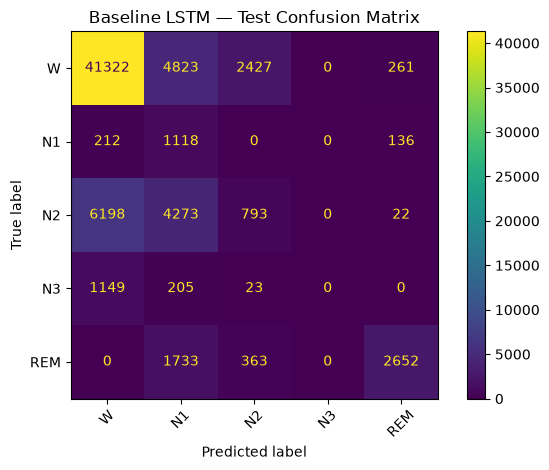

In [93]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
)

cm = confusion_matrix(
    y_test,
    y_test_pred,
)

print("Confusion matrix:")
print(cm)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names,
)

display.plot(
    xticks_rotation=45,
)

plt.title(
    "Baseline LSTM — Test Confusion Matrix"
)

plt.tight_layout()

plt.show()

**Save the baseline LSTM**

In [94]:
BASELINE_MODEL_PATH = (
    PROJECT_ROOT
    / "experiments"
    / "baseline_lstm.keras"
)

BASELINE_MODEL_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

model.save(
    BASELINE_MODEL_PATH
)

print(
    "Baseline model saved to:"
)

print(
    BASELINE_MODEL_PATH
)

Baseline model saved to:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\experiments\baseline_lstm.keras


**Save baseline training history**

In [95]:
history_df = pd.DataFrame(
    history.history
)

HISTORY_PATH = (
    PROJECT_ROOT
    / "experiments"
    / "baseline_lstm_history.csv"
)

history_df.to_csv(
    HISTORY_PATH,
    index=False,
)

print(
    "Training history saved to:"
)

print(
    HISTORY_PATH
)

Training history saved to:
D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\experiments\baseline_lstm_history.csv
